# Extra Analysis

# 1. Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Loading Dataset

In [2]:
df = pd.read_csv('COVID_Parcel_Business.csv')
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['FakeCustomerID', 'THE_YEAR', 'THE_WEEK', 'VOLUME'], dtype='str')


# Finding Required Columns

In [3]:
year_col = None
cust_col = None
week_col = None
parcel_col = None

for col in df.columns:
    col_lower = col.lower().strip()

    if 'year' in col_lower:
        year_col = col
    elif 'cust' in col_lower or 'id' in col_lower:
        cust_col = col
    elif 'week' in col_lower:
        week_col = col
    elif 'volume' in col_lower or 'parcel' in col_lower or 'vol' in col_lower:
        parcel_col = col

if year_col and cust_col and week_col and parcel_col:
    print("Columns detected successfully!")
else:
    print("Error: Could not detect required columns")

Columns detected successfully!


# Defining Business Rules

In [4]:
BASE_COST = 22.0

SEGMENT_DEFS = {
    'Enterprise': {'min': 500001, 'max': float('inf'), 'discount': 0.22},
    'Large': {'min': 200001, 'max': 500000, 'discount': 0.17},
    'Medium': {'min': 10001, 'max': 200000, 'discount': 0.10},
    'Small': {'min': 1000, 'max': 10000, 'discount': 0.04}
}

# Creating Baseline Data

In [5]:
df_pre_covid = df[
    (df[year_col] == 2019) |
    ((df[year_col] == 2020) & (df[week_col] <= 15))
]

df_baseline = df_pre_covid.groupby(cust_col)[parcel_col].sum().reset_index()
df_baseline.rename(columns={parcel_col: 'Vol_Baseline'}, inplace=True)

# Assigning Customer Segment

In [6]:
def get_segment(volume):
    for seg in SEGMENT_DEFS:
        min_val = SEGMENT_DEFS[seg]['min']
        max_val = SEGMENT_DEFS[seg]['max']

        if volume >= min_val and volume <= max_val:
            return seg

    return 'Under 1K/New'

df_baseline['Segment'] = df_baseline['Vol_Baseline'].apply(get_segment)

df = pd.merge(df, df_baseline[[cust_col, 'Segment']], on=cust_col, how='left')
df['Segment'] = df['Segment'].fillna('Under 1K/New')

# Calculating Revenue

In [7]:
def calculate_revenue(row):
    discount = 0

    for seg in SEGMENT_DEFS:
        if row['Segment'] == seg:
            discount = SEGMENT_DEFS[seg]['discount']

    revenue = row[parcel_col] * BASE_COST * (1 - discount)
    return revenue

df['Revenue'] = df.apply(calculate_revenue, axis=1)

# Calculating Industry Growth Rate (ISGR)

In [8]:
vol_2019_pre = df[
    (df[year_col] == 2019) &
    (df[week_col] <= 15)
][parcel_col].sum()

vol_2020_pre = df[
    (df[year_col] == 2020) &
    (df[week_col] <= 15)
][parcel_col].sum()

isgr = ((vol_2020_pre - vol_2019_pre) / vol_2019_pre) * 100

print("ISGR:", round(isgr, 2), "%")

ISGR: 11.4 %


# Calculating Peak Season Growth

In [9]:
peak_2019 = df[
    (df[year_col] == 2019) &
    (df[week_col] >= 45)
][parcel_col].sum()

peak_2020 = df[
    (df[year_col] == 2020) &
    (df[week_col] >= 45)
][parcel_col].sum()

peak_growth = ((peak_2020 - peak_2019) / peak_2019) * 100

print("Peak Growth:", round(peak_growth, 2), "%")

Peak Growth: 28.84 %


# COVID Period Analysis

In [10]:
df_covid = df[
    (df[year_col] == 2020) &
    (df[week_col] >= 16)
]

df_covid = df_covid.groupby(cust_col)[parcel_col].sum().reset_index()
df_covid.rename(columns={parcel_col: 'Vol_COVID'}, inplace=True)

final_df = pd.merge(df_baseline, df_covid, on=cust_col, how='outer')
final_df = final_df.fillna(0)

final_df['Growth_Rate'] = (
    (final_df['Vol_COVID'] - final_df['Vol_Baseline']) /
    final_df['Vol_Baseline'].replace(0, 1)
) * 100

# Customer Classification

In [11]:
def classify(row):

    if row['Vol_Baseline'] == 0 and row['Vol_COVID'] > 0:
        return 'New Customer'
    elif row['Vol_Baseline'] > 0 and row['Vol_COVID'] == 0:
        return 'Lost Customer'

    elif row['Growth_Rate'] > isgr:
        return 'High Growth'
    elif row['Growth_Rate'] >= 0:
        return 'Stable'
    else:
        return 'Declining'

final_df['Status'] = final_df.apply(classify, axis=1)

print(final_df['Status'].value_counts())

Status
Declining        733
High Growth      235
Stable            63
Lost Customer     30
Name: count, dtype: int64


# What percent of 2019 customers in each group did we lose during the COVID observation period?

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('COVID_Parcel_Business.csv')


cust_col = 'FakeCustomerID'
year_col = 'THE_YEAR'
volume_col = 'VOLUME'

df_2019 = df[df[year_col] == 2019]

cust_volume_2019 = df_2019.groupby(cust_col)[volume_col].sum().reset_index()

def assign_group(volume):
    if volume > 500000:
        return 'Enterprise'
    elif 200000 <= volume <= 500000:
        return 'Large'
    elif 10000 <= volume < 200000:
        return 'Medium'
    elif 1000 <= volume < 10000:
        return 'Small'
    else:
        return 'Very Small'

cust_volume_2019['GROUP'] = cust_volume_2019[volume_col].apply(assign_group)

df = df.merge(cust_volume_2019[[cust_col, 'GROUP']], on=cust_col, how='left')

df_2020 = df[df[year_col] == 2020]

customers_2019 = cust_volume_2019.groupby('GROUP')[cust_col].apply(set)
customers_2020 = df_2020.groupby('GROUP')[cust_col].apply(set)

results = []

for group in customers_2019.index:
    base_customers = customers_2019[group]
    covid_customers = customers_2020.get(group, set())

    lost_customers = base_customers - covid_customers

    total_2019 = len(base_customers)
    lost_count = len(lost_customers)

    percent_lost = (lost_count / total_2019) * 100 if total_2019 > 0 else 0

    results.append({
        'Group': group,
        '2019_Customers': total_2019,
        'Lost_Customers': lost_count,
        'Percent_Lost': round(percent_lost, 2)
    })

result_df = pd.DataFrame(results)

result_df.sort_values(by='Percent_Lost', ascending=False)


,Group,2019_Customers,Lost_Customers,Percent_Lost
3,Small,860,14,1.63
2,Medium,174,1,0.57
1,Large,15,0,0.00
0,Enterprise,12,0,0.00


# What was the overall impact of COVID on volumes and revenue by customer group?

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('COVID_Parcel_Business.csv')

cust_col = 'FakeCustomerID'
year_col = 'THE_YEAR'
volume_col = 'VOLUME'
week_col = 'THE_WEEK'
revenue_col = 'Revenue'

BASE_COST = 22.0
SEGMENT_DEFS = {
    'Enterprise': {'min': 500001, 'max': float('inf'), 'discount': 0.22},
    'Large': {'min': 200001, 'max': 500000, 'discount': 0.17},
    'Medium': {'min': 10001, 'max': 200000, 'discount': 0.10},
    'Small': {'min': 1000, 'max': 10000, 'discount': 0.04}
}

df_pre_covid = df[
    (df[year_col] == 2019) |
    ((df[year_col] == 2020) & (df[week_col] <= 15))
]
df_baseline = df_pre_covid.groupby(cust_col)[volume_col].sum().reset_index()
df_baseline.rename(columns={volume_col: 'Vol_Baseline'}, inplace=True)

def get_segment(volume):
    for seg in SEGMENT_DEFS:
        min_val = SEGMENT_DEFS[seg]['min']
        max_val = SEGMENT_DEFS[seg]['max']
        if volume >= min_val and volume <= max_val:
            return seg
    return 'Under 1K/New'
df_baseline['Segment'] = df_baseline['Vol_Baseline'].apply(get_segment)

df = pd.merge(df, df_baseline[[cust_col, 'Segment']], on=cust_col, how='left')
df['Segment'] = df['Segment'].fillna('Under 1K/New')

def calculate_revenue(row):
    discount = 0
    for seg in SEGMENT_DEFS:
        if row['Segment'] == seg:
            discount = SEGMENT_DEFS[seg]['discount']
    revenue = row[volume_col] * BASE_COST * (1 - discount)
    return revenue
df['Revenue'] = df.apply(calculate_revenue, axis=1)

df_2019_for_group = df[df[year_col] == 2019]

cust_volume_2019_for_group = df_2019_for_group.groupby(cust_col)[volume_col].sum().reset_index()

def assign_group_for_current_analysis(volume):
    if volume > 500000:
        return 'Enterprise'
    elif 200000 <= volume <= 500000:
        return 'Large'
    elif 10000 <= volume < 200000:
        return 'Medium'
    elif 1000 <= volume < 10000:
        return 'Small'
    else:
        return 'Very Small'

cust_volume_2019_for_group['GROUP'] = cust_volume_2019_for_group[volume_col].apply(assign_group_for_current_analysis)

df = df.merge(cust_volume_2019_for_group[[cust_col, 'GROUP']], on=cust_col, how='left')

summary = df.groupby(['GROUP', year_col]).agg({
    volume_col: 'sum',
    revenue_col: 'sum'
}).reset_index()

pivot_df = summary.pivot(index='GROUP', columns=year_col)

pivot_df.columns = ['_'.join(map(str, col)) for col in pivot_df.columns]

pivot_df = pivot_df.reset_index()

pivot_df['Volume_%_Change'] = (
    (pivot_df['VOLUME_2020'] - pivot_df['VOLUME_2019']) /
    pivot_df['VOLUME_2019']
) * 100

pivot_df['Revenue_%_Change'] = (
    (pivot_df['Revenue_2020'] - pivot_df['Revenue_2019']) /
    pivot_df['Revenue_2019']
) * 100

pivot_df['Volume_%_Change'] = pivot_df['Volume_%_Change'].round(2)
pivot_df['Revenue_%_Change'] = pivot_df['Revenue_%_Change'].round(2)

pivot_df.sort_values(by='Volume_%_Change')

def format_money(value):
    if pd.isna(value):
        return value
    elif value >= 1e9:
        return f"{value/1e9:.2f}B"
    elif value >= 1e6:
        return f"{value/1e6:.2f}M"
    else:
        return f"{value:.2f}"
    
pivot_df['Revenue_2019_fmt'] = pivot_df['Revenue_2019'].apply(format_money)
pivot_df['Revenue_2020_fmt'] = pivot_df['Revenue_2020'].apply(format_money)

pivot_df['Volume_2019_fmt'] = pivot_df['VOLUME_2019'].apply(format_money)
pivot_df['Volume_2020_fmt'] = pivot_df['VOLUME_2020'].apply(format_money)

pivot_df[['GROUP',
          'Volume_2019_fmt', 'Volume_2020_fmt',
          'Revenue_2019_fmt', 'Revenue_2020_fmt',
          'Volume_%_Change', 'Revenue_%_Change']]

,GROUP,Volume_2019_fmt,Volume_2020_fmt,Revenue_2019_fmt,Revenue_2020_fmt,Volume_%_Change,Revenue_%_Change
0,Enterprise,38.91M,53.79M,667.70M,923.11M,38.25,38.25
1,Large,4.19M,5.63M,76.06M,101.77M,34.20,33.80
2,Medium,7.03M,9.97M,137.49M,194.17M,41.81,41.22
3,Small,2.69M,4.09M,56.32M,85.29M,51.86,51.45


# A. Timeline Chart

<>:105: SyntaxWarning: invalid escape sequence '\p'
<>:105: SyntaxWarning: invalid escape sequence '\p'
C:\Users\abeez\AppData\Local\Temp\ipykernel_26500\1898137520.py:105: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('EXTRA_Analysis_Graphs\project_timeline_trendline_with_peaks_and_lows.png')


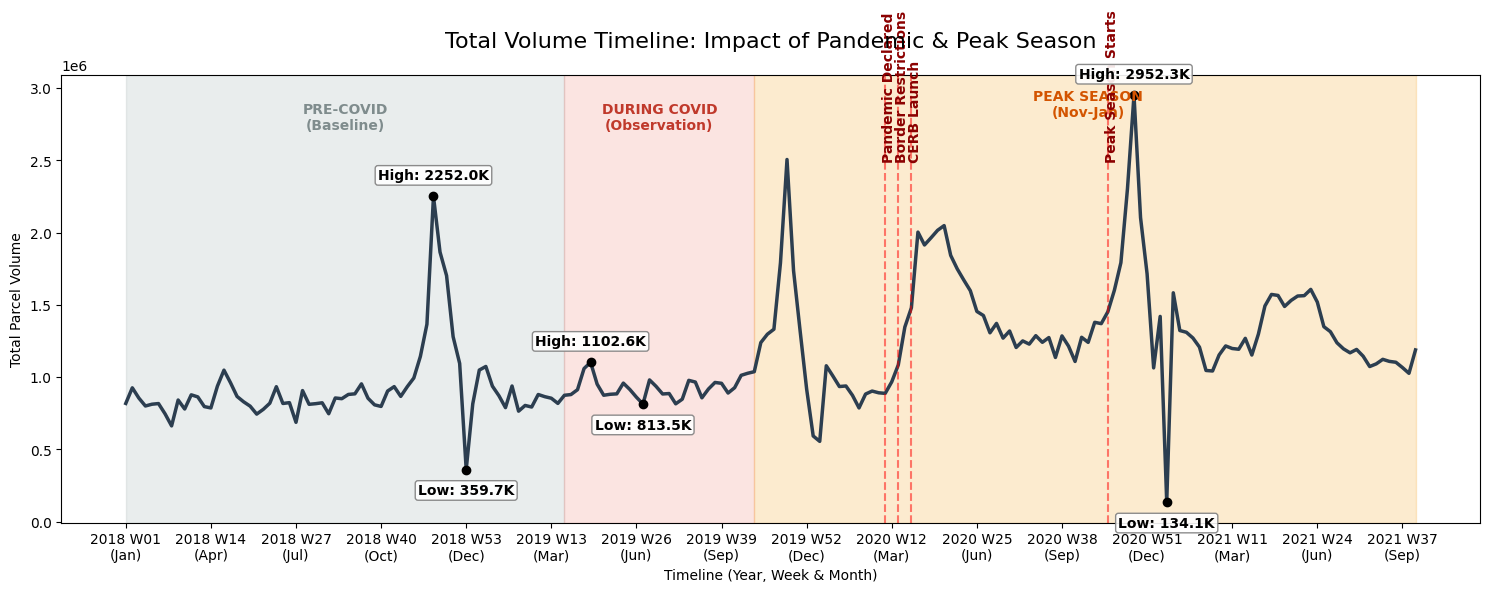

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

trend = df.groupby(['THE_YEAR', 'THE_WEEK'])['VOLUME'].sum().reset_index()

trend['Time'] = trend['THE_YEAR'].astype(str) + " W" + trend['THE_WEEK'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 6))

ax = sns.lineplot(data=trend, x='Time', y='VOLUME', color='#2c3e50', linewidth=2.5)

pre_end = len(trend[(trend['THE_YEAR'] == 2019) | ((trend['THE_YEAR'] == 2020) & (trend['THE_WEEK'] <= 15))]) - 1
during_end = pre_end + len(trend[(trend['THE_YEAR'] == 2020) & (trend['THE_WEEK'] >= 16) & (trend['THE_WEEK'] <= 44)])

plt.axvspan(0, pre_end, color='#95a5a6', alpha=0.2, label='Pre-COVID')
plt.axvspan(pre_end, during_end, color='#e74c3c', alpha=0.15, label='During COVID')
plt.axvspan(during_end, len(trend)-1, color='#f39c12', alpha=0.2, label='Peak Season')

max_vol = trend['VOLUME'].max()
plt.text(pre_end/2, max_vol * 0.92, 'PRE-COVID\n(Baseline)', ha='center', fontweight='bold', color='#7f8c8d')
plt.text(pre_end + (during_end - pre_end)/2, max_vol * 0.92, 'DURING COVID\n(Observation)', ha='center', fontweight='bold', color='#c0392b')
plt.text(during_end + (len(trend) - during_end)/2, max_vol * 0.95, 'PEAK SEASON\n(Nov-Jan)', ha='center', fontweight='bold', color='#d35400')

ticks = list(range(0, len(trend), 13))
custom_labels = []

for i in ticks:
    year_val = trend['THE_YEAR'].iloc[i]
    week_val = trend['THE_WEEK'].iloc[i]
    time_str = trend['Time'].iloc[i]

    safe_week = 52 if week_val > 52 else week_val

    d = datetime.date.fromisocalendar(year_val, safe_week, 4)
    month_name = d.strftime('%b')

    custom_labels.append(f"{time_str}\n({month_name})")

plt.xticks(ticks, custom_labels, rotation=0, fontsize=10)

events = {
    11: 'Pandemic Declared',
    13: 'Border Restrictions',
    15: 'CERB Launch',
    45: 'Peak Season Starts'
}

for week, event in events.items():
    event_index = trend[(trend['THE_YEAR'] == 2020) & (trend['THE_WEEK'] == week)].index

    if not event_index.empty:
        idx = event_index[0]
        plt.axvline(x=idx, linestyle='--', alpha=0.5, color='red')
        plt.text(idx - 0.5, trend['VOLUME'].max() * 0.85, event, rotation=90, color='darkred', fontweight='bold')

pre_covid_data = trend.iloc[0:pre_end+1]
during_covid_data = trend.iloc[pre_end+1:during_end+1]
peak_season_data = trend.iloc[during_end+1:]

peaks = [
    pre_covid_data.loc[pre_covid_data['VOLUME'].idxmax()],
    during_covid_data.loc[during_covid_data['VOLUME'].idxmax()],
    peak_season_data.loc[peak_season_data['VOLUME'].idxmax()]
]

lows = [
    pre_covid_data.loc[pre_covid_data['VOLUME'].idxmin()],
    during_covid_data.loc[during_covid_data['VOLUME'].idxmin()],
    peak_season_data.loc[peak_season_data['VOLUME'].idxmin()]
]

for p in peaks:
    idx = p.name
    vol = p['VOLUME']

    plt.plot(idx, vol, marker='o', markersize=6, color='black')
    plt.annotate(f"High: {vol/1000:.1f}K",
                 xy=(idx, vol),
                 xytext=(0, 10), # Push text up
                 textcoords="offset points",
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='black',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9))

for p in lows:
    idx = p.name
    vol = p['VOLUME']

    plt.plot(idx, vol, marker='o', markersize=6, color='black')
    plt.annotate(f"Low: {vol/1000:.1f}K",
                 xy=(idx, vol),
                 xytext=(0, -10),
                 textcoords="offset points",
                 ha='center', va='top',
                 fontsize=10, fontweight='bold', color='black',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9))
# ------------------------------------------------

plt.title('Total Volume Timeline: Impact of Pandemic & Peak Season', fontsize=16, pad=20)
plt.ylabel('Total Parcel Volume')
plt.xlabel('Timeline (Year, Week & Month)')

plt.tight_layout()
plt.savefig('EXTRA_Analysis_Graphs\project_timeline_trendline_with_peaks_and_lows.png')
plt.show()
plt.close()

# B. Segment Performance Chart

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
C:\Users\abeez\AppData\Local\Temp\ipykernel_26500\362033512.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.savefig('EXTRA_Analysis_Graphs\segment_performance_heatmap.png')


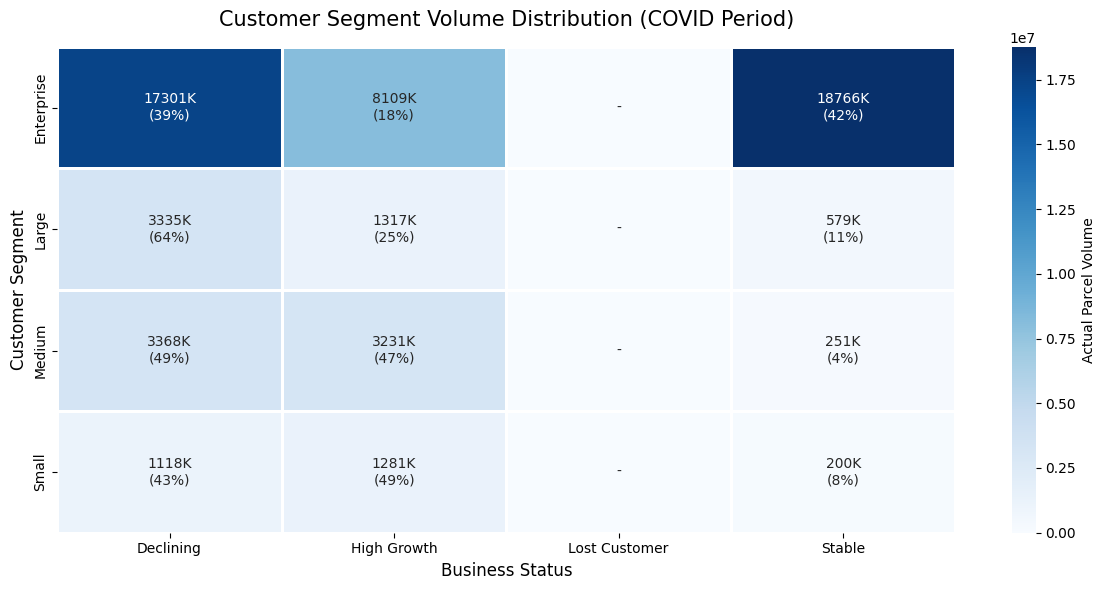

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

volume_summary = final_df.groupby(['Segment', 'Status'])['Vol_COVID'].sum().unstack().fillna(0)

annot_labels = np.empty_like(volume_summary, dtype=object)

for i in range(volume_summary.shape[0]):
    total_vol = volume_summary.iloc[i].sum()
    for j in range(volume_summary.shape[1]):
        raw_vol = volume_summary.iloc[i, j]
        pct = (raw_vol / total_vol) * 100 if total_vol > 0 else 0

        if raw_vol > 0:
          
            annot_labels[i, j] = f"{raw_vol/1000:.0f}K\n({pct:.0f}%)"
        else:
            annot_labels[i, j] = "-" 


plt.figure(figsize=(12, 6))

sns.heatmap(volume_summary, annot=annot_labels, fmt="", cmap="Blues",
            linewidths=1, linecolor='white', cbar_kws={'label': 'Actual Parcel Volume'})

plt.title('Customer Segment Volume Distribution (COVID Period)', fontsize=15, pad=15)
plt.ylabel('Customer Segment', fontsize=12)
plt.xlabel('Business Status', fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('EXTRA_Analysis_Graphs\segment_performance_heatmap.png')
plt.show()
plt.close()

# C. Revenue Pie Chart

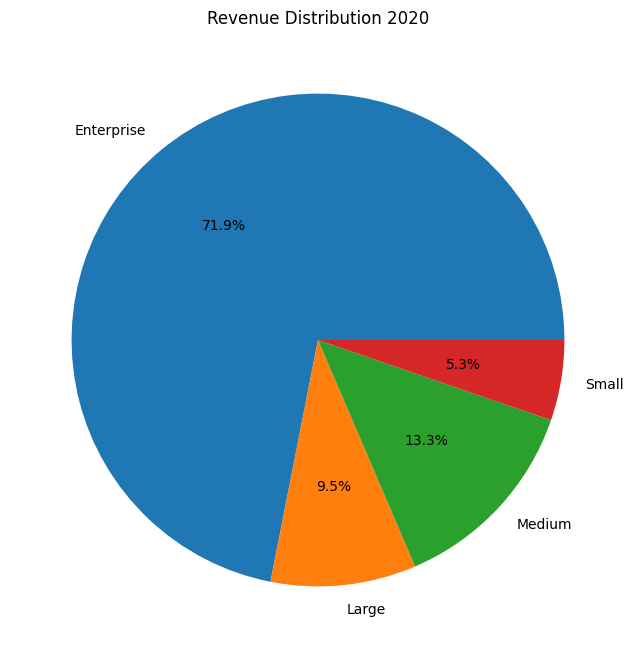

In [16]:
rev_2020 = df[df[year_col] == 2020].groupby('Segment')['Revenue'].sum()

plt.figure(figsize=(8, 8))
plt.pie(rev_2020, labels=rev_2020.index, autopct='%1.1f%%')

plt.title('Revenue Distribution 2020')

plt.savefig('EXTRA_Analysis_Graphs/revenue_impact.png')  # Save
plt.show()                         # Show
plt.close()

Chart 1: Segment Performance by ACTUAL VOLUME
This chart replaces the "number of customers" with the "number of parcels". It shows exactly how many parcels are stable, growing, or declining.

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
C:\Users\abeez\AppData\Local\Temp\ipykernel_26500\3253559637.py:33: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('EXTRA_Analysis_Graphs\pre_covid_customer_distribution.png')


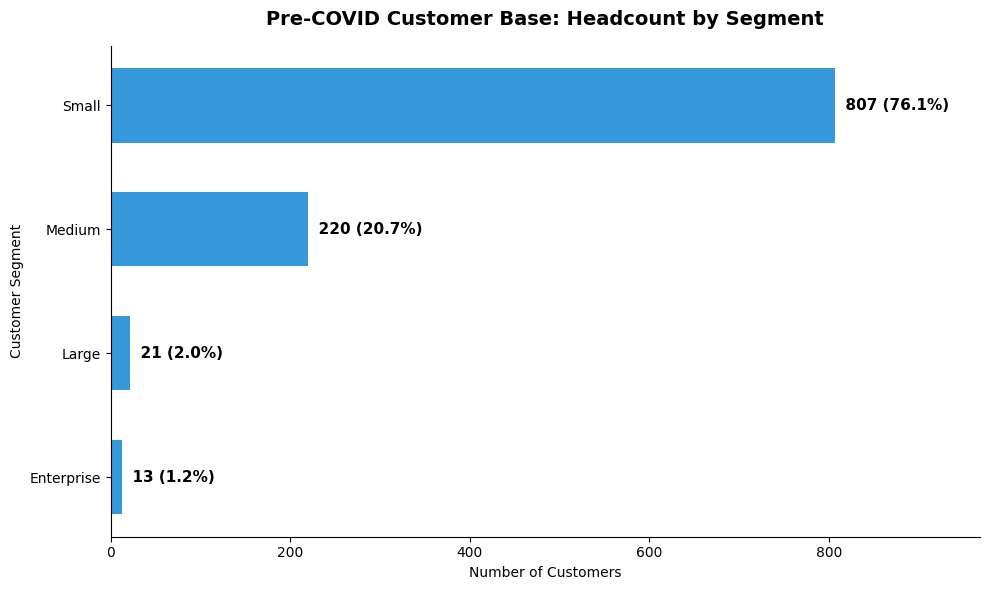

In [17]:
import matplotlib.pyplot as plt

pre_covid_customers = final_df[final_df['Vol_Baseline'] > 0]

baseline_counts = pre_covid_customers.groupby('Segment').size().sort_values(ascending=True)

total_baseline_customers = baseline_counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(baseline_counts.index, baseline_counts.values, color='#3498db', height=0.6)

plt.title('Pre-COVID Customer Base: Headcount by Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

for bar in bars:
    width = bar.get_width()
    pct = (width / total_baseline_customers) * 100

    label_text = f'  {int(width)} ({pct:.1f}%)'

    ax.text(width, bar.get_y() + bar.get_height()/2, label_text,
            va='center', ha='left', fontsize=11, fontweight='bold')

ax.set_xlim(0, baseline_counts.max() * 1.2)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('EXTRA_Analysis_Graphs\pre_covid_customer_distribution.png')
plt.show()
plt.close()

### Executive Insights: Headcount vs. Volume
* **The Visual:** This slopegraph contrasts the high headcount of our smaller accounts against the massive parcel volume driven by a few enterprise clients.
* **The Insight:** It visualizes the 80/20 rule, proving that business retention efforts must prioritize high-volume segments over sheer customer volume.

<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
C:\Users\abeez\AppData\Local\Temp\ipykernel_26500\3894497872.py:47: SyntaxWarning: invalid escape sequence '\s'
  plt.savefig('EXTRA_Analysis_Graphs\slopegraph_comparison.png')


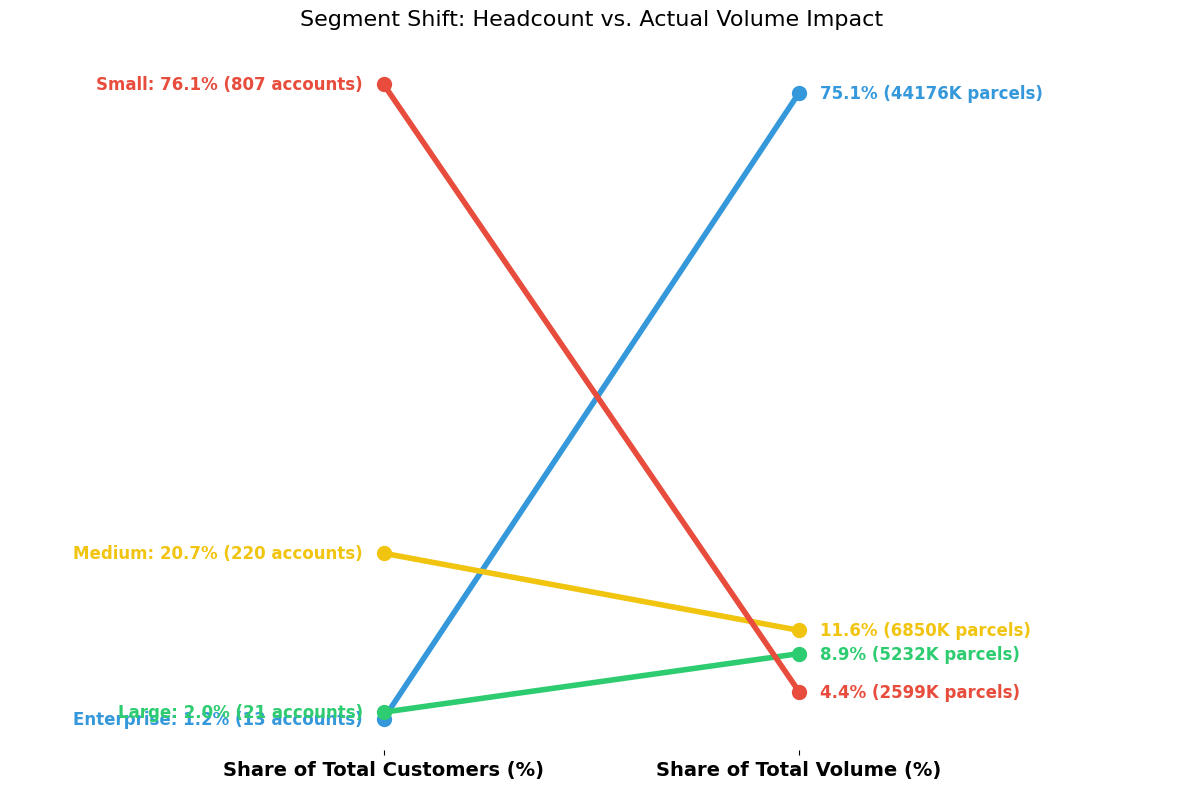

In [18]:
compare_df = final_df.groupby('Segment').agg(
    Total_Customers=('FakeCustomerID', 'count'),
    Total_Volume=('Vol_COVID', 'sum')
).reset_index()

compare_df['% of Customers'] = (compare_df['Total_Customers'] / compare_df['Total_Customers'].sum()) * 100
compare_df['% of Volume'] = (compare_df['Total_Volume'] / compare_df['Total_Volume'].sum()) * 100

fig, ax = plt.subplots(figsize=(12, 8))

x_left = 1
x_right = 2

colors = {'Enterprise': '#3498db', 'Large': '#2ecc71', 'Medium': '#f1c40f', 'Small': '#e74c3c'}

for i, row in compare_df.iterrows():
    seg = row['Segment']
    y_cust = row['% of Customers']
    y_vol = row['% of Volume']
    raw_cust = int(row['Total_Customers']) 
    raw_vol = row['Total_Volume']          

    ax.plot([x_left, x_right], [y_cust, y_vol], marker='o', markersize=10,
            linewidth=4, color=colors.get(seg, 'gray'))

    ax.text(x_left - 0.05, y_cust, f"{seg}: {y_cust:.1f}% ({raw_cust} accounts)",
            ha='right', va='center', fontsize=12, fontweight='bold', color=colors.get(seg, 'gray'))

    ax.text(x_right + 0.05, y_vol, f"{y_vol:.1f}% ({raw_vol/1000:.0f}K parcels)",
            ha='left', va='center', fontsize=12, fontweight='bold', color=colors.get(seg, 'gray'))

ax.set_xticks([x_left, x_right])
ax.set_xticklabels(['Share of Total Customers (%)', 'Share of Total Volume (%)'],
                   fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.title('Segment Shift: Headcount vs. Actual Volume Impact', fontsize=16, pad=20)

plt.xlim(0.1, 2.9)

plt.tight_layout()
plt.savefig('EXTRA_Analysis_Graphs\slopegraph_comparison.png')
plt.show()
plt.close()

## Profitability Analysis: Impact of Segment Discounts
This analysis explores whether the high volume from Enterprise customers compensates for the deep 22% discounts they receive. We evaluate the **Profit Margin** to determine the financial health of each segment during the COVID period.

--- Profitability Analysis by Segment (2020) ---
                 Revenue        Profit  Profit_Margin_%
Segment                                                
Enterprise  9.379570e+08  1.180645e+08        12.587413
Large       1.243375e+08  2.219826e+07        17.853231
Medium      1.732444e+08  4.199864e+07        24.242424
Small       6.879196e+07  1.993403e+07        28.977273


C:\Users\abeez\AppData\Local\Temp\ipykernel_26500\3983826516.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_summary.index, y='Profit_Margin_%', data=profit_summary, palette='viridis')


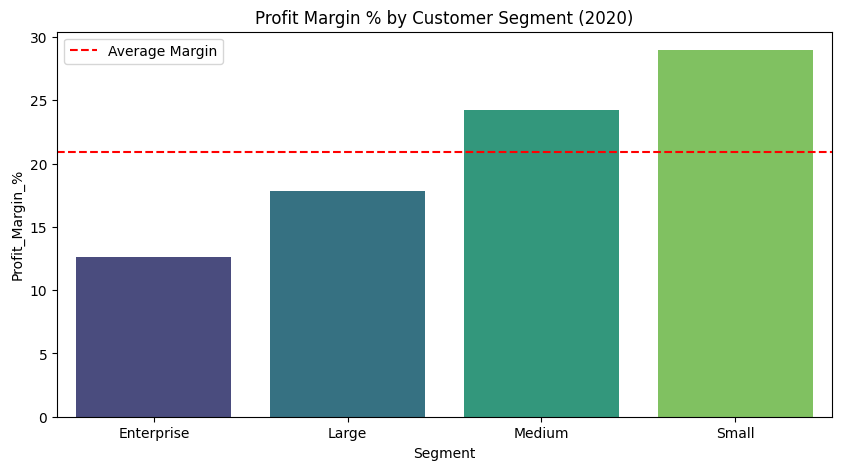

In [19]:
INTERNAL_COST_PER_PARCEL = 15.00

df_2020 = df[df[year_col] == 2020].copy()
df_2020['Total_Cost'] = df_2020[parcel_col] * INTERNAL_COST_PER_PARCEL
df_2020['Profit'] = df_2020['Revenue'] - df_2020['Total_Cost']

profit_summary = df_2020.groupby('Segment').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    parcel_col: 'sum'
})

profit_summary['Profit_Margin_%'] = (profit_summary['Profit'] / profit_summary['Revenue']) * 100

print("--- Profitability Analysis by Segment (2020) ---")
print(profit_summary[['Revenue', 'Profit', 'Profit_Margin_%']])

plt.figure(figsize=(10, 5))
sns.barplot(x=profit_summary.index, y='Profit_Margin_%', data=profit_summary, palette='viridis')
plt.title('Profit Margin % by Customer Segment (2020)')
plt.axhline(profit_summary['Profit_Margin_%'].mean(), color='red', linestyle='--', label='Average Margin')
plt.legend()
plt.show()

## Statistical Significance: Pre-COVID vs. COVID Observation Period
We use an **Independent T-Test** to verify if the difference in weekly shipping volumes before and after the pandemic declaration (Week 11) is statistically significant (p-value < 0.05).

In [21]:
from scipy import stats

weekly_vol_2020 = df[df[year_col] == 2020].groupby(week_col)[parcel_col].sum()

pre_covid_vols = weekly_vol_2020[weekly_vol_2020.index <= 11]
post_covid_vols = weekly_vol_2020[weekly_vol_2020.index > 11]

t_stat, p_val = stats.ttest_ind(pre_covid_vols, post_covid_vols)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The impact of COVID-19 on parcel volumes is Statistically Significant.")
else:
    print("Conclusion: The change in volume is not statistically significant.")

T-Statistic: -5.1765
P-Value: 0.0000
Conclusion: The impact of COVID-19 on parcel volumes is Statistically Significant.


## External Correlation: Parcel Volume vs. Canadian COVID-19 Cases
By integrating public data from the Government of Canada, we visualize how national case counts correlate with ABC Company's shipping spikes.

Correlation Analysis Results:
Pearson Correlation Coefficient: 0.51


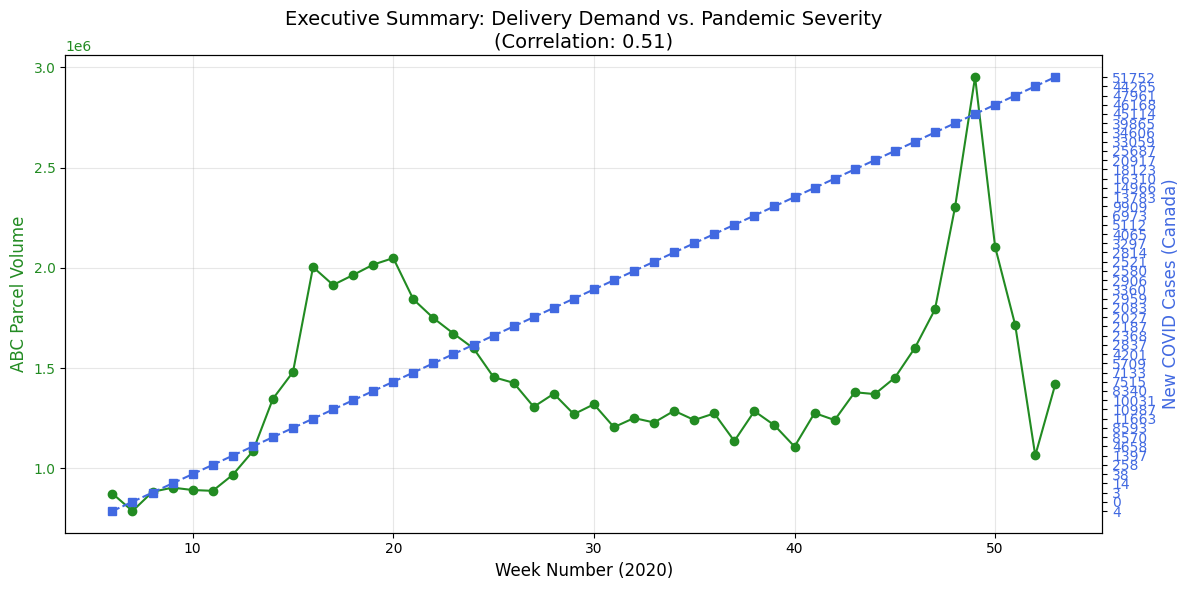


Insight: There is a MODERATE correlation between case counts and delivery demand.


In [22]:
covid_data_url = "https://health-infobase.canada.ca/src/data/covidLive/covid19-download.csv"
external_df = pd.read_csv(covid_data_url)

case_col = 'numtotal_last7'
year_col_ext = 'reporting_year'
week_col_ext = 'reporting_week'

if case_col not in external_df.columns:
    print(f"Error: Could not find {case_col}. Available: {external_df.columns.tolist()}")
else:
    external_2020 = external_df[
        (external_df[year_col_ext] == 2020) &
        (external_df['prname'] == 'Canada')
    ].copy()

    weekly_cases = external_2020.groupby(week_col_ext)[case_col].sum()

    business_weekly = df[df[year_col] == 2020].groupby(week_col)[parcel_col].sum()

    correlation_df = pd.DataFrame({
        'Cases': weekly_cases,
        'Volume': business_weekly
    }).dropna()

    corr_val = correlation_df['Cases'].corr(correlation_df['Volume'])
    print(f"Correlation Analysis Results:")
    print(f"Pearson Correlation Coefficient: {corr_val:.2f}")

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()


    ax1.plot(correlation_df.index, correlation_df['Volume'], color='forestgreen', marker='o', label='Parcel Volume')
    ax1.set_xlabel('Week Number (2020)', fontsize=12)
    ax1.set_ylabel('ABC Parcel Volume', color='forestgreen', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='forestgreen')
    ax1.grid(True, alpha=0.3)

    ax2.plot(correlation_df.index, correlation_df['Cases'], color='royalblue', linestyle='--', marker='s', label='Weekly COVID Cases')
    ax2.set_ylabel('New COVID Cases (Canada)', color='royalblue', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='royalblue')

    plt.title(f'Executive Summary: Delivery Demand vs. Pandemic Severity\n(Correlation: {corr_val:.2f})', fontsize=14)
    fig.tight_layout()
    plt.show()

    if corr_val > 0.7:
        print("\nInsight: There is a STRONG positive correlation. As COVID cases increased, parcel volume rose significantly.")
    elif corr_val > 0.4:
        print("\nInsight: There is a MODERATE correlation between case counts and delivery demand.")
    else:
        print("\nInsight: There is a WEAK correlation, suggesting other factors (like the shift to e-commerce) were more influential than case counts alone.")

## Sales Intelligence: Top 5 Growth Leaders and Bottom 5 Declining Customers
We identify specific high-value targets for the sales team—focusing on those who expanded rapidly during COVID and those who may require intervention due to steep declines.

--- Top 5 Customers (Highest Growth) ---
     FakeCustomerID Segment  Growth_Rate
846          832038   Small  1622.655602
492          496278   Small  1242.556303
987          937860  Medium   507.105577
150          220475   Small   436.072542
795          783818   Small   412.424446

--- Bottom 5 Customers (Steepest Decline) ---
     FakeCustomerID Segment  Growth_Rate
973          926759   Small       -100.0
352          378111   Small       -100.0
702          700956   Small       -100.0
954          909527   Small       -100.0
928          891939   Small       -100.0


C:\Users\abeez\AppData\Local\Temp\ipykernel_26500\3858109358.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cust_col, y='Growth_Rate', data=extreme_performance, palette='coolwarm')


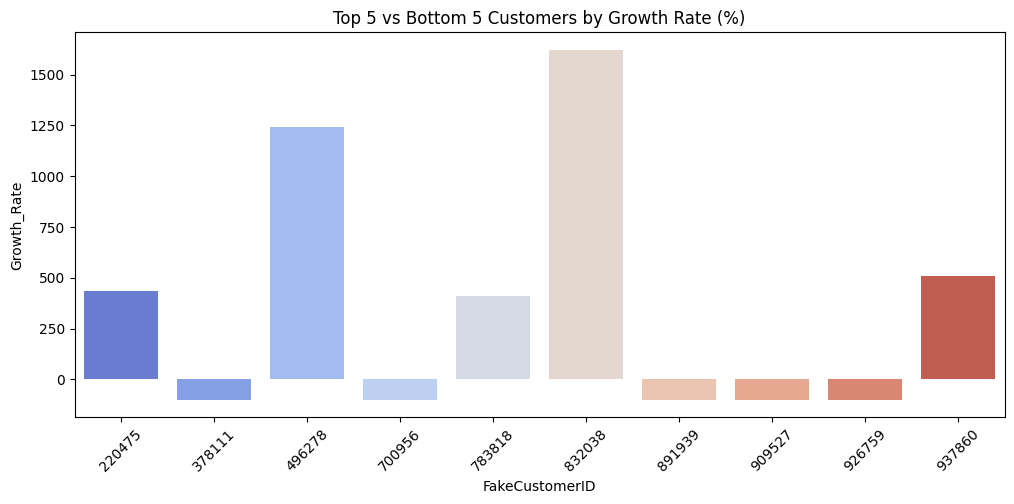

In [23]:
existing_customers = final_df[final_df['Vol_Baseline'] > 0].copy()

top_performers = existing_customers.sort_values(by='Growth_Rate', ascending=False).head(5)
bottom_performers = existing_customers.sort_values(by='Growth_Rate', ascending=True).head(5)

print("--- Top 5 Customers (Highest Growth) ---")
print(top_performers[[cust_col, 'Segment', 'Growth_Rate']])

print("\n--- Bottom 5 Customers (Steepest Decline) ---")
print(bottom_performers[[cust_col, 'Segment', 'Growth_Rate']])

extreme_performance = pd.concat([top_performers, bottom_performers])
plt.figure(figsize=(12, 5))
sns.barplot(x=cust_col, y='Growth_Rate', data=extreme_performance, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Top 5 vs Bottom 5 Customers by Growth Rate (%)')
plt.show()